![alt text](images/uspas.png)
# Fundamentals of Accelerator Physics and Technology
### (with Simulations and Measurements Lab)
# Computer Lab: Longitudinal Motion
##### Author: E. Harms, N. Neveu, K. Ruisard, N. Evans

This worksheet demonstrates phase space motion in the longitudinal degree of freedom.   
Questions to be answered and turned in for grade are typeset in **Bold** Type.

## **NOTE!!!** Number of turns in this lab refers to the number of turns the particle travels around the ring.

### Python Notes:
- Press shift+enter to execute a cell, or use the play button at the top of the window
- Make sure you exectue cells in order, or re-execute cells if you change something at the top of the notebook.
- You can also execute the whole notebook by using 'Run all cells' under the 'Run' tab.
- Repeated variables are appended with a number (1,2,3) indicating the section they belong to.
- '2**2' represents two squared, i.e. 2^2
- A colon (:) means all values in that dimension. i.e. array[:,2] = all rows, second column


</br>
Also helpful: Shift+right click brings up OS/browser right-click menu, can copy image or save.

----------

In [ ]:
%matplotlib inline

In today's lab we will be examining the 1-d motion of particles in longitudinal phase space. In some ways the motion is similar to transverse (quadrupole) focusing, but there are also key differences.

In longitudinal phase-space, the "position" variable is taken to be the angle $\phi$ in the RF waveform. In our phase convention, the RF voltage waveform is taken to vary as $\sim \sin(\phi)$, with $\phi$ related to the accelerator RF frequency $f$ by $\phi = 2\pi f t$. So the RF phase $\phi$ is easily translated to the time $t$ and can also be related to the axial position $s$ in the lattice. In transverse dynamics, the quadrupole focusing strength varies linearly with position (focusing strength $\propto k x$). In longitudinal dynamics, the focusing strength has a nonlinear sinusoidal dependence $\propto \sin{\phi}$. This means there are phase intervals near the ideal design trajectory that are linear, but nonlinear effects occur with large phase deviations from the design trajectory.

We take the "momentum" (or slope) variable in longitudinal dynamics to be $\Delta E$, which is the deviation in kinetic energy. $\Delta E << E$, meaning particles in an accelerated bunch are mostly traveling at the same velocity.

Instead of the ideal design orbit in longitudinal dynamics, we refer to the *synchronous* particle. The synchronous particle has the design RF phase ($\phi = \phi_s$) and energy ($E = E_s$) as it advances through the accelerator. For a particle held at fixed energy (no energy gain), the synchronous phase is $\phi_s = 0$. For a particle that is being accelerated, but still below transition energy, the synchronous phase is typically chosen to be $\phi_s = 30^\circ$ to provide both acceleration and longitudinal focusing.

## 1. Longitudinal Phase Space Motion

The difference equations for longitudinal motion of a particle of charge $e$ in a synchrotron can be written as:

$\Delta E_{n+1} = \Delta E_n + eV (sin \phi_n - sin \phi_s)$

$\phi_{n+1} = \phi_n + \frac{2 \pi h \eta}{E} \Delta E_{n+1}$

$n$ is the lap index of the particle traversing the cavity,

$V$ is the RF voltage,

$h$ is the RF harmonic number in the ring,

$\eta=1/\gamma_T^2-1/\gamma^2$ is the slip factor.

These equations can also be applied to an RF linac, though typically an alternative RF phase convention is applied for linacs.  

The following cells allow the user to enter specified initial conditions (i.e. various $\phi_0$, $\Delta E_0$) of an array of particles and “track” their motion for a specified number of iterations.

In the worksheet program, the user can vary the parameters of the basic equations of motion to produce phase space plots in $\Delta E_0 -\phi$ coordinates.  
The default parameters are typical of Fermilab Main Injector operation at its injection energy.  
By inputting various initial conditions we will explore the motion of particles in phase space region under various parameter regimes.  

Note in the code below, the initial energy deviations $\Delta E$ are different for each particle but they are all launched from the same initial phase, $\phi = 0$.


In [2]:
#Importing the libraries we need
#Importing plotting library
import numpy as np
import matplotlib
from matplotlib import pyplot as plt

#Defining some variables
#These will be used later
h           = 588                #constant = 588
cavityField = 800000.            #Cavity field in Volts
e_chg       = 1.602*10**-19      #fundamental charge in Coulombs
eV          = cavityField*e_chg  #cavity field*particle charge in Joules
GeV         = e_chg*10**9        #constant = 10**9*e_chg
MeV         = GeV*10**-3         #constant = GeV*10**-3

In [3]:
################################
# Do not change this cell
################################

def run_exercise1(initial_deltaE,initial_phases,nturns1,phi_s1,E_s1,rf_voltage_factor):
    g_t1    = 21.8          # gamma_t: initial = 21.8
    eta1    = 1/g_t1**2 - (0.938*GeV)**2 / E_s1**2
    beta_s1 = np.sqrt(1 - ( (0.938*GeV) / E_s1 )**2 )  # Relativistic beta
    k1      = (2*np.pi*h*eta1)/(beta_s1**2 * E_s1)  # coefficent (2pi h eta)/ E

    #Tracking n Particles
    #Change phi_vals[:,0] and dE_0[:,0] below to change the plot.
    n       = len(initial_deltaE)      #number of particles: initial = 5

    # Creating some arrays to hold the data
    dE_vals1  = np.zeros((n,nturns1))
    phi_vals1 = np.zeros((n,nturns1))

    #Setting initial conditions:
    dE_vals1[:,0]  = np.array(initial_deltaE)*MeV    # Initial Energy of particles in MeV: 2,4,6,8,10
    phi_vals1[:,0] = np.deg2rad(initial_phases)      # Intial Phase of particles: 0,0,0,0,0

    #Calculating dE and phase for each particle for nturns.
    for i in range(0,nturns1-1):
        #Angles
        radians1 = phi_vals1[:,i]

        #dE_n+1 = dE_n + eV* ( sin(phi_n) - sin(phi_s) )
        dE_vals1[:,i+1]  = dE_vals1[:,i] + eV*rf_voltage_factor*( np.sin(radians1) - np.sin(phi_s1) )

        #phi_n+1 = phi + k * dE_n + eV ( sin(phi_n) - sin(phi_s) )
        phi_vals1[:,i+1] = radians1 + k1* ( dE_vals1[:,i] + eV*rf_voltage_factor* ( np.sin(radians1) - np.sin(phi_s1)) )

    #Setting resolution of plot (changes size too)
    matplotlib.rcParams['figure.dpi'] = 100 #initial = 100, Increase number for bigger plots

    # Plotting the data
    degrees1    = np.rad2deg(phi_vals1) #Deg
    plt.plot(degrees1,dE_vals1/MeV, '.', markersize=1)
    plt.plot(degrees1[:,0],dE_vals1[:,0]/MeV,'or')
    plt.xlabel('Phase [deg]', size=14)
    plt.ylabel('$\Delta$ Energy [MeV]', size=14)


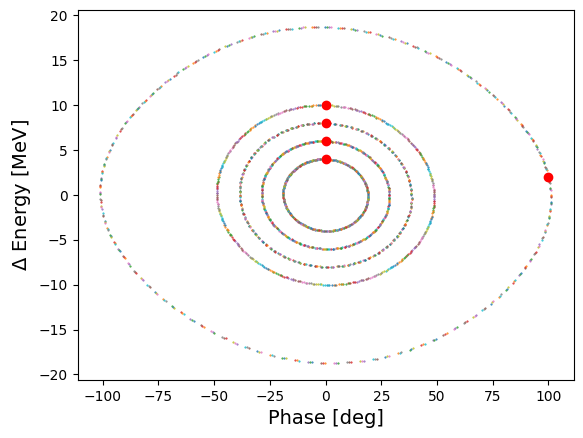

In [4]:
################################
# Change parameters in this cell
################################
initial_deltaE = [2,4,6,8,10,] # Values are in MeV initial: [2,4,6,8,10]
initial_phases = [100.,0.,0.,0.,0.] # Values are in deg initial: [0,0,0,0,0]
nturns1 = 400    #number of turns the particles travel: initial = 400
phi_s1  = np.deg2rad(0) #Synchronous phase: initial = 0, units:radians
E_s1    = 8*GeV         # Energy: initial = 8 GeV
rf_voltage_factor = 1

# run script
run_exercise1(initial_deltaE,initial_phases,nturns1,phi_s1,E_s1,rf_voltage_factor)
#plt.xlim([-200,200]); plt.ylim([-500,500])

**Q1) The plot you see initially should show stable orbits on closed ellipses. At large energy offsets we expect very different behavior. By changing the initial energy of one particle in the array `initial_deltaE` in small steps (~1 MeV steps to start are convenient) find the largest initial energy that will remain trapped within the RF bucket (meaning, the orbit will remain near the synchronous phase `phi_s=0`.**

Please specify in MeV to at least one decimal place (eg, 10.0)


**Q2) We call the boundary between well-behaved elliptal orbits about the synchronous particle and untrapped motion that you found in Q1 the 'separatrix'. What happens to the particles that find themselves outside of this separatrix – are they lost from the synchrotron?**


**Q3) For particles that are still within, but very close to the separatrix, how many turns does it take to complete one revolution in the phase space? Use the initial conditions $(\phi, \Delta E) = (0,\Delta E_{max})$ where $\Delta E_{max}$ is your answer to Q1. In $(\phi, \Delta E)$ coordinates, where are the stable and unstable fixed points?**


---
Change the synchronous phase, `phi_s`, to `\phi_s = 30` degrees. Consider what happens in a synchrotron when this phase change occurs.  
Under these conditions...

**Q4) What maximum value (approximately) of $\Delta E$ can remain trapped about the synchronous particle now?**

Hint: It may help to find this value if you modify `initial_phases` as well, since the stable point has changed from $0^{\circ}$ to $30^{\circ}$.


**Q5) What happens to the particles that find themselves outside of the separatrix – are they lost from the synchrotron?  Explain your reasoning.**


**Q6) For particles that are still within, but very close to the separatrix, how many turns does it take to complete one revolution in the phase space? Use the initial conditions $(\phi, \Delta E) = (0,\Delta E_{max})$ where $\Delta E_{max}$ is your answer to Q5. In $(\phi, \Delta E)$ coordinates, where are the stable and unstable fixed points?**


---
Next, set `initial_deltaE` back to `[2,4,6,8,10]` and change `nturns1` to 1000, leave the other parameters as they are, and change the energy of the synchronous particle, $E_s$, from 8 GeV to 150 GeV.  

**Q7) By changing the values in `initial_phases` locate the stable phase region - where is the stable fixed point?.**  
(Note: The transition energy of the Main Injector is about 22 GeV; if you've covered this in lecture - what happens at transition?)



**Q8) What maximum $\Delta E$ will remain within the RF bucket of the synchronous particle now?**
Hint - you may need to increase the number of turns.



---
The user should feel free to play with the parameters of the program. We recommend using the parameters of your “favorite” accelerator and explore the longitudinal phase space. Be sure to change the scales of the plot axes in order to see the results.

#### Optional:
Since the difference equations are of a non-linear system, one can push the parameters until resonance islands, chaos, and other non-linear effects are found.

- Go back to the “stationary bucket” case `phi_s1  = 0`
- Restore beam energy to initial value, `E_s1 = 8*GeV`
- Since increasing the RF voltage increases the accepted range of `\Delta_E`, it is better to initialize orbits in `phi` instead. Set `initial_deltaE = [0,0,0,0,0]` and `initial_phases = [40,80,120,160,179]`.
- It will be helpful to fix the plot axes. Do this by un-commenting the line `plt.xlim([-200,200]); plt.ylim([-500,500])` in the cell above.
- Increase the voltage by a factor of 10 (by setting `rf_voltage_factor = 10`) and look at the phase space;
- Another factor of 10; another; and so on.
- Can you find other regions of stability in the phase space?
- Is there a value of the RF voltage for which the entire phase space becomes unstable?


----

## 2. Synchrotron Tune vs. Oscillation Amplitude

In section #1, you should have noticed that the frequency at which a particle circulates in longitudinal phase space decreases when the particle approaches the separatrix -   especially near the “unstable fixed points”. To measure the synchroton tune in a real accelerator, we don't normally have access to the energy deviations $\Delta E$ of the beam, and have to settle for a measurement of the phase alone. By looking at the frequency of the particle oscillation in the RF phase $\phi$, we can deduce the synchrotron tune. The numerical tool we use to extract frequency from phase data is called a `Discrete Fourier Transform (DFT)`, which is typically referred to with the name of an efficient numerical algorithm called the `Fast Fourier Transform (FFT)`. The Python FFT algorithm allows efficient extraction of frequency/tune from the data of a regularly sampled longitudinal particle orbit. In this section we will apply an FFT to simulated data from the Fermilab Main Injector.

The following code is similar to the previous code, but tracks a single particle. The motion of that particle is then analyzed using the FFT function, and the frequency (or, in this case, the synchrotron “tune”) of the particle’s motion is estimated by finding the strongest (fundamental) peak in the plot of the FFT output.
This analytical expression for the synchrotron tune for small-amplitude oscillations about the synchronous particle is reproduced in Python so that the result of the FFT can be directly compared with the analytical result.

- Track a particle for 254 turns (Note: The FFT calculation requires that one track for (2^n)-2 turns, where n is an integer.)
- Use the initial conditions `phi_0 = 0` and `particle_dE = 1*MeV`.
- These should be the default values when the notebook is evaluated.

Comment:  The Python FFT function is NOT an FFT only.  It is a discrete Fourier Transform.  So the data length need not strictly be 2^n, but the calculation is most efficient for 2^n points.

In [ ]:
################################
# Do not change this cell
################################

def run_exercise2(nturns2,particle_dE,phi_0):
    # Don't change anything below here!
    phi_s2  = 0             # Synchronous phase: initial = 0
    E_s2    = 8*GeV         # Energy: initial = 8GeV
    g_t2    = 21.8          # gamma_t: constant = 21.8
    eta2    = 1/g_t2**2 - (0.938*GeV)**2 / E_s2**2
    beta_s2 = np.sqrt(1 - ( (0.938*GeV) / E_s2 )**2 ) # Relativistic beta
    k2      = (2*np.pi*h*eta2)/(beta_s2**2 * E_s2)    # coefficent (2pi h eta)/ E

    # The analytical small amplitude synchrotron tune is:
    numerator   = h*eta2*eV*np.cos(phi_s2)
    denominator = 2*np.pi*beta_s2**2*E_s2
    nu_s        = np.sqrt(-numerator/denominator) # analytical tune

    # Creating some arrays to hold the data
    dE_vals2  = np.zeros((nturns2+1))
    phi_vals2 = np.zeros((nturns2+1))

    #Setting initial conditions:
    voltage      = 800*1.6*10**-16 # voltage constant = 800 e*kV
    dE_vals2[0]  = np.array(particle_dE) # Initial Energy of particles in MeV: 1 MeV
    phi_vals2[0] = np.deg2rad(phi_0)   # Intial Phase of particles: 0

    #Calculating dE and phase for each particle for nturns.
    for i in range(0,nturns2):
        #Angles
        radians2 = phi_vals2[i]

        #dE_n+1 = dE_n + eV* ( sin(phi_n) - sin(phi_s) )
        dE_vals2[i+1]  = dE_vals2[i] + voltage*( np.sin(radians2) - np.sin(phi_s2) )

        #phi_n+1 = phi + k * dE_n + eV ( sin(phi_n) - sin(phi_s) )
        phi_vals2[i+1] = radians2 + k2* ( dE_vals2[i] + voltage* ( np.sin(radians2) - np.sin(phi_s2)) )

    #Setting resolution and size of plots
    matplotlib.rcParams['figure.dpi'] = 60 #initial = 100, Increase number for bigger plots

    # Plotting the data
    degrees2 = np.rad2deg(phi_vals2) #Deg
    plt.plot(degrees2,dE_vals2/MeV, '.', markersize=1)
    plt.xlabel('Phase [deg]', size=14)
    plt.ylabel('$\Delta$ Energy [MeV]', size=14)

    # Plotting phase of particles
    plt.figure()
    plt.plot(degrees2)
    plt.ylabel('Phase [deg]', size=14)
    plt.xlabel('Turn ', size=14)

    # Calculating FFT
    n   = len(degrees2)            # length of the signal
    frq = np.arange(n)/n           # two sides frequency range
    Y   = np.fft.fft(degrees2) # fft computing
    Y   = Y/max(abs(Y))        # normalization

    # calculating tune from fft
    nu_fft =  frq[np.argmax(abs(Y))]
    if nu_fft>.5:
        nu_fft = 1 - nu_fft
    error       = nu_s-nu_fft
    percent_err = (error/nu_s)*100

    #Plotting FFT
    plt.figure()
    plt.plot(frq, abs(Y), '-')
    plt.ylabel('$|fft|$', size=14)
    plt.xlabel(r'$\nu_j$', size=14)
    plt.xlim(-0.1, 0.5)

    #Calculating percent error for Q9
    print('analytical tune:', nu_s)
    print('FFT Tune:', nu_fft)
    print('Percent error:', abs(percent_err))

analytical tune: 0.01051099655637781
FFT Tune: 0.011764705882352941
Percent error: 11.927597152664001


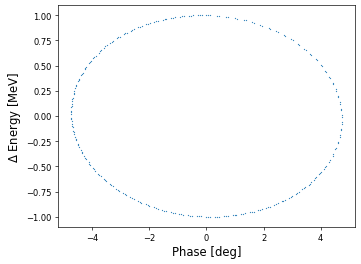

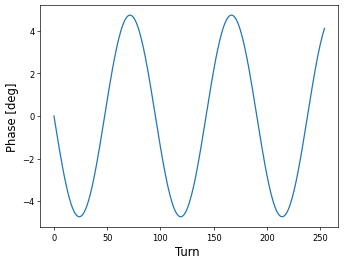

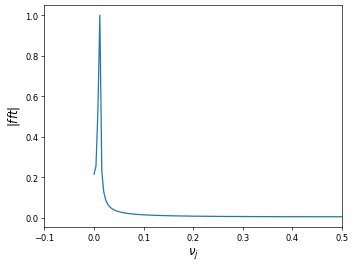

In [ ]:
################################
# Change parameters in this cell
################################

#Tracking 1 Particle

nturns2 = 254 # number of turns to track: initial = 254
particle_dE = 1*MeV # Initial energy error of particle. initial = 1MeV
phi_0 = 0

# script
run_exercise2(nturns2,particle_dE,phi_0)


**Q9) What synchrotron tune does the FFT of the tracking data show? How does this compare with the analytically predicted value?**

**Q10) For what number of turns is the FFT result within 5% of the predicted result?**  Comment: The program will work for 'nturns2' integer (not just `2^n-2`).  Please limit yourself to `2^n-2` turns in your answer.

---

Next, tracking over 1022 turns, slowly raise the initial `Delta E` from 1 MeV (steps of 2 MeV are good) and keep track of the synchrotron tune. Record your numbers in the arrays in the next cell, so you can plot them.

How does the tune behave?*


**Q11) Using the cell below, make a plot of `nu_FFT` vs. `Delta_E` for `Delta_E` from 1 MeV to 26 MeV.**
- Note the value of `Delta E` at the separatrix.

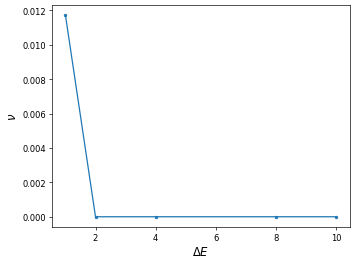

In [ ]:
################################
# Use this cell to make the plot for Q11
################################

nu_fft = np.array([0.01172,0,0,0,0]) #.... continue filling in array
dE_fft = np.array([1,2,4,8,10])      #.... continue filling in array

plt.figure()
plt.plot(dE_fft, nu_fft, '.-')
plt.ylabel(r'$\nu$', size=14)
plt.xlabel(r'$\Delta E$', size=14)
plt.show()

---
## 3. Injecting beam into a stationary bucket

To efficiently reach high energies, we typically send the beam through a sequence of different accelerating structures. This may be a complex of synchrotron rings with increasing energy and radius, or a sequence of different cavity structures in a linac. As the beam is transferred ring-to-ring, or cavity-to-cavity, it is important to make sure that the beam parameters are lined up with the acceptance of accelerating structure. We call this a *matched* beam, when the phase space ellipse occupied by particles line up well with the stable regions of phase space created by the RF cavity fields. This is analagous to the concept of transverse matching, where we want the particle distribution to overlap with the phase-space ellipse defined by the lattice functions. Transverse matching is explored further in the Quadrupole-Focusing lab.

In this section, we will trace a distribution of 500 particles as they evolve in a stationary bucket RF system with $\phi_s = 0$. This initial bunch has just been injected from an upstream accelerator into this fixed-energy ring. You will change the initial parameters of the particle distribution as well as the RF voltage to simulate the effect of longitudinal mismatch between the injected beam and the RF acceptance.


The first cell below generates the initial longitudinal particle distribution. It is matched to the contours of the RF system (superimposed on plot) that we have been studying in the previous two sections. Note that the contours resemble the plots from Section 1. Individual particles follow these contours. Particles within the *separatrix* will be focused and remain within the bunch, while particles that find themselves outside the separatrix will be lost from the bunch.

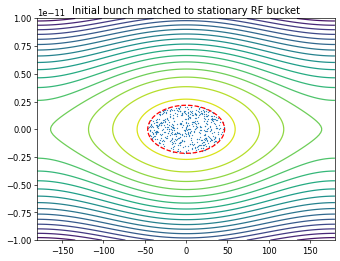

In [ ]:
#################################################
### This cell generates the particle distribution
#################################################

# variables controlling the particle distribution
# You do not have to change for this exercise,
# but you can experiment with different values if you like
# Set back to default before continuing
phi_s = np.deg2rad(0)     # stationary bucket, radians, default=0
H_max = 8e-14 / (2*np.pi) # maximum action in bunch, default=8e-14 / (2*np.pi)
nparticles= 500           # number of particles in bunch, default = 500

###########################
## Don't change below
###########################

#Defining variables
g_t3    = 21.8  # gamma_t: initial = 21.8
phi_sf3 = 0    # Synchronous phase: initial = 0
E_s3    = 8*GeV # synchronous energy: initial = 8*GeV
eta3    = 1/g_t3**2 - (0.938*GeV)**2 / E_s3**2
beta_s3 = np.sqrt(1 - ( (0.938*GeV) / E_s3 )**2 )  # Relativistic beta
k3      = (2*np.pi*h*eta3)/(beta_s3**2 * E_s3)     # coefficent (2pi h eta)/ (beta^2 E)

# -- make contours
voltage_upstream = 1.6*MeV # cavity voltage of upstream accelerator
dE_gv = np.linspace(-1e-11,1e-11,100)
phi_gv = np.linspace(-np.pi,np.pi,101)
PHI,DE = np.meshgrid(phi_gv,dE_gv,indexing='ij')
HGRID = k3/(4*np.pi)*DE**2 + voltage_upstream/(2*np.pi)*(np.cos(PHI) - np.cos(phi_s) + (PHI - phi_s)*np.sin(phi_s))


# -- make particles
phi_init = np.array([phi_s])
dE_init = np.array([0])
counter = 1
while counter < nparticles:
    phi_i =(np.random.random(1)*2 - 1)*np.pi
    dE_i = (np.random.random(1)*2 - 1)* np.sqrt(-H_max*(4*np.pi)/k3)
    H_i =  k3/(4*np.pi)*(dE_i)**2 + voltage_upstream/(2*np.pi)*(np.cos(phi_i) - np.cos(phi_s) + (phi_i - phi_s)*np.sin(phi_s))
    if np.abs(H_i) < H_max:
        phi_init = np.hstack([phi_init,phi_i])
        dE_init = np.hstack([dE_init,dE_i])
        counter += 1

plt.plot(np.rad2deg(phi_init),dE_init,'.C0',markersize=1,alpha=1)
plt.contour(np.rad2deg(PHI),DE,HGRID,21)
plt.contour(np.rad2deg(PHI),DE,HGRID,[-H_max],colors='r');
plt.title('Initial bunch matched to stationary RF bucket');

The following cell will evolve this distribution through the ring. Two plots are generated.

1. The first shows the longitudinal statistical or rms *emittance*. This is calculated from the particle distribution, using the definition:

    $\epsilon_z= \sqrt{\left< \phi^2 \right>\left<\Delta E^2 \right> - \left< \phi \Delta E\right>^2}$.

    $\left< \phi^2 \right> = \frac{\sum_{i=0..n} \phi_i^2}{ n}$

    $\left< \Delta E^2 \right> = \frac{\sum_{i=0..n} \Delta E^2_i }{n}$

    $\left< \phi \Delta E \right> = \frac{\sum_{i=0..n} \phi_i \Delta E_i }{ n}$
    
2. The second set of plots shows snapshots of the distribution in phase-space as it evolves through `Nturns` turns. The variable `nplots` controls how many phase-space snapshots to show. In addition to our distribution (plotted in blue), we trace 10 particles (plotted in black) that are launched at the same energy $\Delta E = 0$ but with varying initial phase within the bucket.


Initially, the beam is injected matched to the RF system. Execute the cell below to view matched transport.





In [ ]:
###########################
## Don't change below
###########################

def run_exercise3(voltage_error, injection_phase_error,injection_energy_error,Nturns,nplots,plot_tracers_Flag,ntracers):

    # -- cavity voltage
    voltage = (1.6 * voltage_error)*MeV # cavity voltage: initial = 1.6*MeV

    # Making data arrays
    n = nparticles + ntracers
    phi_vals3 = np.zeros([n,Nturns+1])
    dE_vals3  = np.zeros([n,Nturns+1])
    H = np.zeros([n,Nturns+1])
    ez_vals3  = np.zeros([Nturns+1])


    # Initial conditions
    # -- first 10 particles are tracers; start these at same phase
    dE_vals3[0:ntracers,0]  = np.array(np.zeros(ntracers))*MeV # Initial Energy of particles in MeV
    phi_vals3[0:ntracers,0] = np.deg2rad(np.linspace(0,50,ntracers))   # Intial Phase of particles in degrees: 0,0,0,0,0

    # -- rest of particles are distributed on contours of Hamiltonian
    phi_vals3[ntracers:,0] = phi_init + np.deg2rad(injection_phase_error)
    dE_vals3[ntracers:,0]  = dE_init + injection_energy_error*MeV


    # -- initial emittance
    idx = list(range(ntracers,n))
    phisq = np.mean(np.rad2deg(phi_vals3[idx,0]-phi_sf3)**2)
    dEsq = np.mean(((dE_vals3[idx,0])/MeV)**2)
    phidE = np.mean(np.rad2deg(phi_vals3[idx,0]-phi_sf3)*(dE_vals3[idx,0])/MeV)
    ez_vals3[0] = np.sqrt(phisq*dEsq - phidE**2)

    # -- initial action
    H[:,0] = k3/(4*np.pi)*(dE_vals3[:,0])**2 + voltage/(2*np.pi)*(np.cos(phi_vals3[:,0]) - np.cos(phi_sf3) + (phi_vals3[:,0] - phi_sf3)*np.sin(phi_sf3))
    H_max_bunch = np.min(H[:,0])

    # Looping through Nturns turns
    for i in range(0,Nturns):

        #Angles
        radians3 = phi_vals3[:,i]

        #dE_n+1 = dE_n + eV* ( sin(phi_n) - sin(phi_s) )
        dE_vals3[:,i+1]  = dE_vals3[:,i] + voltage*( np.sin(radians3) - np.sin(phi_sf3) )

        #phi_n+1 = phi + k * dE_n + eV ( sin(phi_n) - sin(phi_s) )
        phi_vals3[:,i+1] = phi_vals3[:,i] + k3* ( dE_vals3[:,i] + voltage* ( np.sin(phi_vals3[:,i]) - np.sin(phi_sf3)) )

        # -- emittance calculation
        phisq = np.mean(np.rad2deg(phi_vals3[idx,i+1]-phi_sf3)**2)
        dEsq = np.mean(((dE_vals3[idx,i+1])/MeV)**2)
        phidE = np.mean(np.rad2deg(phi_vals3[idx,i+1]-phi_sf3)*(dE_vals3[idx,i+1])/MeV)
        ez_vals3[i+1] = np.sqrt(phisq*dEsq - phidE**2)

        # -- action
        H[:,i+1] = k3/(4*np.pi)*(dE_vals3[:,i+1])**2 + voltage/(2*np.pi)*(np.cos(phi_vals3[:,i+1]) - np.cos(phi_sf3) + (phi_vals3[:,i+1] - phi_sf3)*np.sin(phi_sf3))

    # Plotting the emittance
    plt.figure(figsize=[12,3])
    plt.plot(np.arange(0,Nturns+1),ez_vals3/ez_vals3[0],label='emittance')
    # -- plot averaged emittance
    winsize = 70
    ez_avg = np.convolve(ez_vals3, np.ones(winsize)/winsize, mode='valid')
    plt.plot(np.arange(winsize/2-1,Nturns-winsize/2+1),ez_avg/ez_vals3[0],color='k',label='rolling average')
    plt.legend()
    # -- adjust limits
    yl = plt.ylim()
    if (yl[1]-yl[0] < .05):
        plt.ylim([.99,1.05])
    # -- labels and legends
    #plt.xticks(np.arange(0,Nturns,70))
    plt.xlim([0,Nturns])
    plt.grid(True)
    plt.xlabel('Turns')
    plt.ylabel('Emittance [arb. units]')


    degrees3 = np.rad2deg(phi_vals3) #Deg
    turns_to_plot = list(np.linspace(0,Nturns,nplots).astype(int))
    ncols = 4
    nrows = int(np.ceil(len(turns_to_plot)/ncols))
    plt.figure(figsize=[12,3*nrows])
    for i in range(len(turns_to_plot)):
        plt.subplot(nrows,ncols,i+1)
        HGRID = k3/(4*np.pi)*DE**2 + voltage/(2*np.pi)*(np.cos(PHI) - np.cos(phi_sf3) + (PHI - phi_sf3)*np.sin(phi_sf3))
        plt.contour(np.rad2deg(PHI),DE/MeV,HGRID,11);
        yl = plt.ylim(); xl = plt.xlim()
        plt.contour(np.rad2deg(PHI),DE/MeV,HGRID,[H_max_bunch],colors='r',alpha=1)
        plt.plot(degrees3[ntracers:,int(turns_to_plot[i])],dE_vals3[ntracers:,int(turns_to_plot[i])]/MeV, '.C0', markersize=1,alpha=1)
        if plot_tracers_Flag:
            plt.plot(degrees3[:ntracers,int(turns_to_plot[i])],dE_vals3[:ntracers,int(turns_to_plot[i])]/MeV, '.-k', markersize=5,alpha=1)
        plt.title('Turn = %i'%int(turns_to_plot[i]))
        plt.xlim(xl); plt.ylim(yl)
    plt.tight_layout()


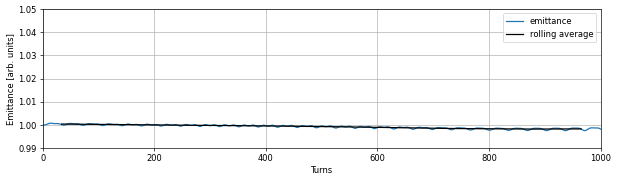

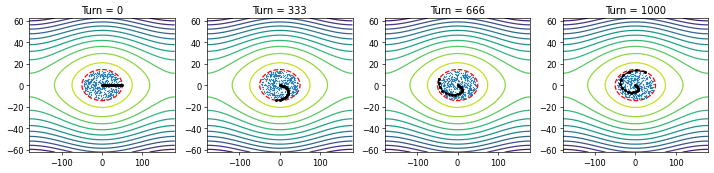

In [ ]:
###########################
## Change these variables
###########################
# -- errors
voltage_error = 1 # multiplicative factor, initial = 1
injection_phase_error = 0 # initial phase shift, units=degrees, initial=0
injection_energy_error = 0 # initial energy offset, units=MeV, initial=0

# -- plotting
Nturns = 1000 # number of turns to plot. Initial=1000
nplots = 4 # number of frames to plot. Initial=4
plot_tracers_Flag = True # initial=True
ntracers= 20

# -- run script
run_exercise3(voltage_error, injection_phase_error,injection_energy_error,Nturns,nplots,plot_tracers_Flag,ntracers)

Consider the 10 particles plotted in black, which initially form a straight line in phase space.

**Q12) Do higher amplitude particles (those furthest from the synchronous particle) circulate in phase space faster or slower than low-amplitude particles?**

This spiraling is a result of the amplitude-dependent tune that you measured in Section 2. The amplitude dependence arises from the fact that the focusing in the RF bucket is nonlinear.  The focusing strength decreases the farther particles get from the center of the RF bucket.

Now, we will look at the effect of various errors.
- In order to view the distribution more clearly, turn off the black trace by setting `plot_tracer_Flag = False`.
- Increase the number of plots to `nplots=8`.


The red contour highlights the field contour of the particle with the highest amplitude. In other words, the outermost particle will be constrained to this contour.


### 3.1 Voltage mismatch

The bunch is matched to a voltage of 1.6 MV. The variable `voltage_error` is a multiplicative factor ('voltage_error'= 1 is design). Try several different errors in the range 2 - 10 and note the effect on the particle distribution and emittance.  Also note that the initial coordinates of the bunch are the same in each case - the only the amplitude of the RF field is changing.

Set `voltage_error` to 10. The elongation of the original ellipse to a spiral with thin arms is a process known as *filamentation.*

**Q13) When you increase the RF voltage, what happens to the width of the RF bucket in energy? In phase? Also describe the effect on the rms emittance.**

Set `voltage_error` to 5. You should see that emittance grows about 35% and then saturates after around 500 turns.

**Q14) What is happening to the initially mismatched beam that causes rms emittance growth? Why does that growth saturate?**


### 3.2 Timing error

Emittance can also grow if we don't inject the beam at the right RF phase. In other words, we need to carefully control the relative timing of the downstream RF system with the upstream RF system.

First restore the value `voltage_error=1`. Then, slowly increase the variable `injection_phase_error` in steps of 5-10 degrees up to 45 degrees.

**Q15) Does the beam stay at the injected phase, or become centered at the synchronous phase ($\phi=0$)?**

**Q16) If we require that emittance growth be below 1%, to what precision do we need to be able to control the timing?**

Give your answer in nanoseconds. Assume the RF frequency is $f=100$ MHz.

Hint: you may need to increase 'Nturns' to see the saturation of emittance at 1%.

### 3.3 Injection energy error

Depending on the application, emittance growth is not always a bad thing. High intensity proton machines transport beams with large emittance to mitigate resonance effects that get worse at high beam phase-space densities due to *space charge* effects. In the J-PARC synchroton in Japan, off-energy injection is used to increase the longitudinal beam emittance to reduce deleterious space-charge effects.

Return `injection_phase_error=0`. Use the parameter `injection_energy_error` to explore the effect of off-energy injection.

**Q17) If you need to reduce the beam phase-space density to 80% of its initial (injected) value, what energy error would you use?** Give answer to a precision of 1 MeV and as a fractional error $\frac{\delta E}{E}$.

Note that the synchronous energy of this system is set at 8 GeV.


---
## 4. Extra credit: Injection to Acceleration

In the Fermilab main injector, beam is initially injected into stationary (non-accelerating) RF buckets. After injection, the synchronous phase must be changed from $\phi_s = 0^{\circ}$ (stationary) to $\phi_s = 30^{\circ}$ (accelerating phase). An abrupt change will be disruptive and cause the longitudinal emittance to increase. An adiabatic change is better, where system parameters change slowly enough that they do no disturb the particle dynamics. In this section we examine what happens when phase is changed too quickly, and find the rate of change to reach the adiabatic condition.


This program tracks a single particle in longitudinal phase space, and varies the RF synchronous phase linearly from $\phi_s=0$ to a final value $\phi_{sf} = 30^{\circ}$  used for acceleration. The “injection porch” length – the number of turns particles spend at the injection energy – is input with the parameter `Nporch`. The number of turns over which the synchronous phase is changed is `Nramp`. The number of turns spent at the accelerating phase is `Nfinal`. The program plots $\phi_s$ versus turn number.

In [ ]:
###########################
## Don't change below
###########################
def run_exercise4(Nporch4,Nramp4,Nfinal4,Nmax,Nturns):

    #Defining variables
    g_t4    = 21.8  # gamma_t: initial = 21.8
    phi_sf4 = 30    # Synchronous phase: initial = 30
    E_s4    = 8*GeV # synchronous energy: initial = 8*GeV
    eta4    = 1/g_t4**2 - (0.938*GeV)**2 / E_s4**2
    beta_s4 = np.sqrt(1 - ( (0.938*GeV) / E_s4 )**2 )  # Relativistic beta
    k4      = (2*np.pi*h*eta4)/(beta_s4**2 * E_s4)     # coefficent (2pi h eta)/ E

    # Making data arrays
    phi_vals4 = np.zeros([Nturns+1])
    dE_vals4  = np.zeros([Nturns+1])
    synch_phase = np.zeros([Nturns+1])

    # Initial conditions
    voltage      = 1.6*MeV # voltage: initial = 1.6*MeV
    phi_vals4[0] = 0       # phase of particle, initial = 0
    dE_vals4[0]  = 1*MeV # Energy spread of particle, dE = 1 MeV
    synch_phase[0] = 0

    # Looping through Nmax turns
    for n in range(0,Nturns):
        # -- synchronous phase schedule
        if n < Nporch4:
            synch_phase[n+1] = np.deg2rad(0)
        elif (n >= Nporch4) and (n<(Nramp4+Nporch4)):
            synch_phase[n+1] = np.deg2rad(phi_sf4*(n-Nporch4)/(Nramp4))
        else:
            synch_phase[n+1] = np.deg2rad(30)

        #Angles
        radians4 = phi_vals4[n]

        #dE_n+1 = dE_n + eV* ( sin(phi_n) - sin(phi_s) )
        dE_vals4[n+1]  = dE_vals4[n] + voltage*( np.sin(radians4) - np.sin(synch_phase[n+1]) )

        #phi_n+1 = phi + k * dE_n + eV ( sin(phi_n) - sin(phi_s) )
        phi_vals4[n+1] = radians4 + k4* ( dE_vals4[n] + voltage* ( np.sin(radians4) - np.sin(synch_phase[n+1])) )


    #Setting resolution and size of plots
    matplotlib.rcParams['figure.dpi'] = 100


    # Plotting the data
    plt.figure(figsize=[12,4])
    plt.subplot(121)
    Nf       = Nmax #Number of turns to plot: initial = 900
    degrees4 = np.rad2deg(phi_vals4) #Deg
    idx1 = np.arange(0,Nporch4).astype(int); idx1 = idx1[idx1<Nturns]
    idx2 = np.arange(Nporch4,Nporch4+Nramp4).astype(int); idx2 = idx2[idx2<Nturns]
    idx3 = np.arange(Nporch4+Nramp4,Nmax).astype(int); idx3 = idx3[idx3<Nturns]

    plt.plot(degrees4[idx2],dE_vals4[idx2]/MeV, '-', markersize=1,color=(.5,.5,.5))
    plt.plot(degrees4[idx1],dE_vals4[idx1]/MeV, '-', markersize=1,color='r')
    plt.plot(degrees4[idx3],dE_vals4[idx3]/MeV, '-', markersize=1,color='b')
    plt.xlabel('Phase [deg]', size=14)
    plt.ylabel('$\Delta$ Energy [MeV]', size=14)
    plt.title('Motion of single particle in phase space')
    plt.grid()


    # -- show ramp in phase
    plt.subplot(122)
    plt.plot(np.rad2deg(synch_phase),'--',label='Synchronous phase of RF system')
    plt.plot(idx2,degrees4[idx2], '-', markersize=1,color=(.5,.5,.5),label='parabolic ramp')
    plt.plot(idx1,degrees4[idx1], '-', markersize=1,color='r',label='Injection porch')
    plt.plot(idx3,degrees4[idx3], '-', markersize=1,color='b',label='Full acceleration')
    plt.ylabel('Phase [deg]', size=14)
    plt.xlabel('turns', size=14)
    plt.title('Phase of single particle during injection and ramp')
    plt.legend(loc='upper left',bbox_to_anchor=(0,-.2))
    plt.show()

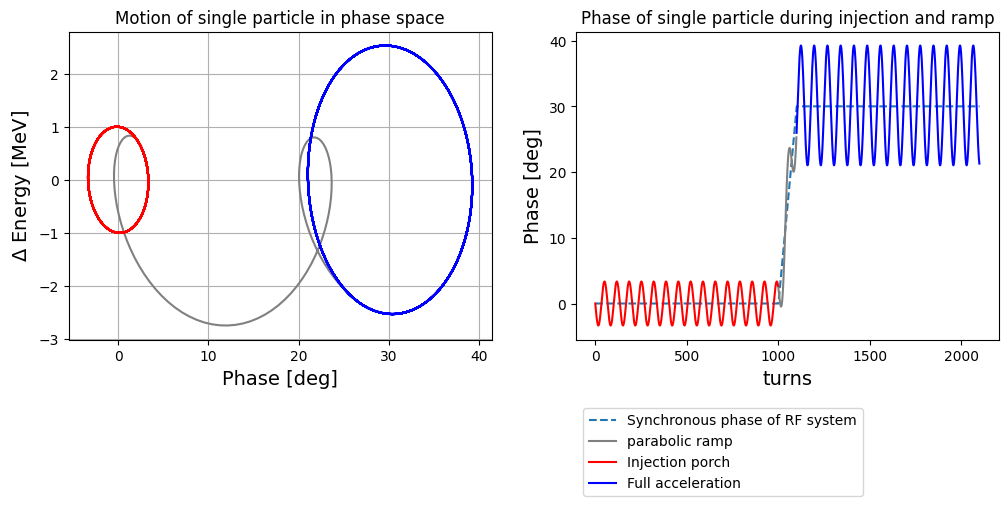

In [ ]:
###########################
## Change these variables
###########################
Nporch4 = 1000 # injection porch length: intial = 1000
Nramp4 = 100  # time to reach final acceleration rate: inital = 1000
Nfinal4 = 1000 # plateau after ramp; initial=1000
Nmax    = Nporch4 + Nramp4 + Nfinal4 # Max number of turns
Nturns = Nmax # number of turns to plot. Initial 100

# run script
run_exercise4(Nporch4,Nramp4,Nfinal4,Nmax,Nturns)


**Q18) By changing the value of `Nporch4` , find the synchrotron period at the Injection Porch (How many turns does it take to close the red circle?)** Give your answer to an accuracy of $\pm5$ turns.


The plot will only show points from 0 to `Nturns`. set `Nturns=Nmax` to view all turns, including the final acceleration plateau.


---

We will start by examining the effect of a non-adiabatic ramp on both a single particle's motion and the distribution of particles. Initially, the system is configured for an adiabatic ramp. The synchronous phase is changed from $\phi_s = 0^\circ$ degrees (stationary) to $\phi_s = 30^\circ$ degrees (accelerating) in only 10 turns, `Nramp4 = 10`.

- In the left plot, note how the particle’s phase space trajectory follows the synchronous phase as it moves from 0 to 30 degrees.
- In the right plot, note how the area encompassed by the particle's orbit in phase space (the ellipse) increases dramatically as a result of the fast ramp.

- In general, if the motion is to be adiabatic, then the system parameters must change much more slowly than the period of the motion. **Make a prediction on how many turns are needed based on your answer to Q18.**

- **Gradually increase the ramp time to find an adiabatic conditon.** Start with steps of ~100 turns.

The transformation is adiabatic when the *action* of the particle is conserved - that is, the area of the ellipse traced in phase space does not grow during transport.

**Q19) At what number of turns does the ramp start to look adiabatic?**

There are some phasing effects that can give low emittance growth at certain low turn numbers that are not adiabatic, so to be sure that you've found the adiabatic condition add 20+ turns to your answer and check that this solution still preserves ellipse area.
